# Practical: Solving Ordinary Differential Equations Numerically


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

---

## Part 0 — Intro

Before diving in, let's anchor where we are.

In the **numerical integration** chapter, your goal was to compute a single number — the area under a known curve:

$$\int_a^b f(x)\, dx \approx \sum_i w_i f(x_i)$$

The function $f(x)$ was **fully known**. You were just sampling it smartly.

In this chapter, the situation is different. You're looking for an **unknown function** $y(t)$ that satisfies a relationship between itself and its own rate of change:

$$\frac{dy}{dt} = f(t,\, y), \qquad y(t_0) = y_0$$

Notice the key shift: **$f$ depends on $y$**, which is what you're trying to find. You can't evaluate $f$ without knowing $y$, and you don't know $y$ without solving the equation. This circularity is what makes ODEs a distinct problem.

Rather than producing a single scalar, you will produce a **trajectory** — the value of $y$ at every time step from $t_0$ to some final time $t_f$.

---

## Part 1 — Context: Quenching a Steel Component

### What is quenching, and why does it matter?

In materials processing, **heat treatment** is used to control the microstructure of metals — and therefore their mechanical properties (hardness, toughness, ductility). A common step is **quenching**: rapidly cooling a hot metal part by plunging it into a liquid bath (water, oil, or brine).

Why does the cooling *rate* matter? Because at different temperatures, different phase transformations occur inside the metal. Cool too slowly and you get a soft microstructure. Cool fast enough and you can trap a hard phase (martensite in steels). Engineers need to predict and control this temperature profile precisely.

Even if you're not from a materials background, the core idea is general: **you have a system whose rate of change depends on its current state**, and you need to track how it evolves over time. This pattern appears in chemical reactor design, drug pharmacokinetics, population dynamics, and countless other fields.

---

### The governing equation

For a well-mixed metal part losing heat to a surrounding bath, Newton's Law of Cooling gives:

$$\frac{dT}{dt} = -k\,(T - T_{\text{bath}})$$

where:
- $T(t)$ — temperature of the part at time $t$ (what we want to find)
- $T_{\text{bath}}$ — temperature of the quench bath (fixed boundary condition)
- $k$ — a cooling constant that depends on the geometry and material properties

**Notice:** the right-hand side depends on $T$, which is the unknown. This is the hallmark of an ODE.

## Part 2 — Questions

1. You are told that at $t = 0$ s, $T_0 = 900$ °C. Would that help you solve this equation? Briefly explain how.

2. Use an LLM of your choice to plot the temperature of the part over the interval $t \in [0, 20]$ s using Euler's method.

3. Based on the code produced in Q2, describe Euler's method step by step in point form.

4. What would you expect to happen to the accuracy of Euler's method if you increased or decreased the stepsize in Euler's method?

5. Repeat Q2 using the Runge-Kutta (RK4) method, this time including the Euler result and the analytical solution on the same plot. The analytical solution is given by:
   $$T_{\text{exact}} = T_{\text{bath}} + (T_0 - T_{\text{bath}})\, e^{-kt}$$
   Note that such a closed-form expression is not always available — particularly for more complex or nonlinear ODEs.

6. What makes RK4 different from Euler's method?



## Answers

### Q1. Initial condition

Yes. The value $T(0)=900\,{ }^{\circ}\mathrm{C}$ is essential, so we can actually define a singular solution to the ODE.


### Assumptions used for Q2 and Q5


- $T_0 = 900\,{}^{\circ}\mathrm{C}$
- $T_{\text{bath}} = 25\,{}^{\circ}\mathrm{C}$
- $k = 0.20\ \mathrm{s}^{-1}$
- step size $h = 0.5\ \mathrm{s}$



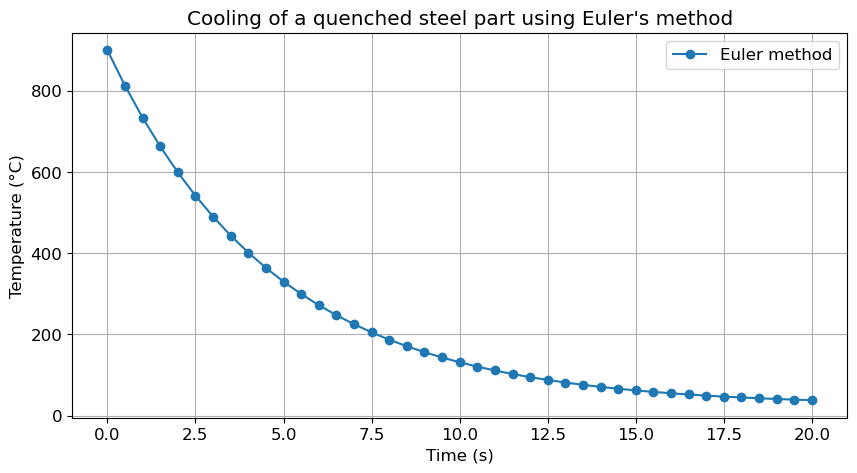

In [2]:
# Q2: Euler's method for Newton's law of cooling
import numpy as np
import matplotlib.pyplot as plt

T0 = 900.0
T_bath = 25.0
k = 0.20
h = 0.5

def dTdt(t, T):
  return -k * (T - T_bath)

t = np.arange(0.0, 20.0 + h, h)
T_euler = np.zeros_like(t)
T_euler[0] = T0

for i in range(len(t) - 1):
  T_euler[i + 1] = T_euler[i] + h * dTdt(t[i], T_euler[i])

plt.figure()
plt.plot(t, T_euler, marker='o', label='Euler method')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title("Cooling of a quenched steel part using Euler's method")
plt.grid(True)
plt.legend()
plt.show()


### Q3. Euler's method step by step

1. Choose the ODE
2. Choose the known starting value: $T(0)=T_0=900\,{}^{\circ}\mathrm{C}$.
3. Pick a stepsize $h$.
4. Create time points from $t=0$ to $t=20$ s.
5. Set the first temperature value equal to the initial condition.
6. At the current point $(t_i, T_i)$, evaluate the slope using the ODE:
  $$f(t_i, T_i) = -k(T_i - T_{\text{bath}}).$$
7. Assume that slope stays constant over one small step.
8. Move forward using Euler's update formula:
  $$T_{i+1} = T_i + h f(t_i, T_i).$$
9. Repeat this process until the final time is reached.


### Q4. Effect of stepsize on accuracy

- Decreasing step size makes it more accurate, as you essentially draw more tangential secants, and vice versa.
- If the stepsize becomes too large, Euler's method can even give a noticeably distorted curve or become unstable for some ODEs.
- Small step sizes become more computationally complex


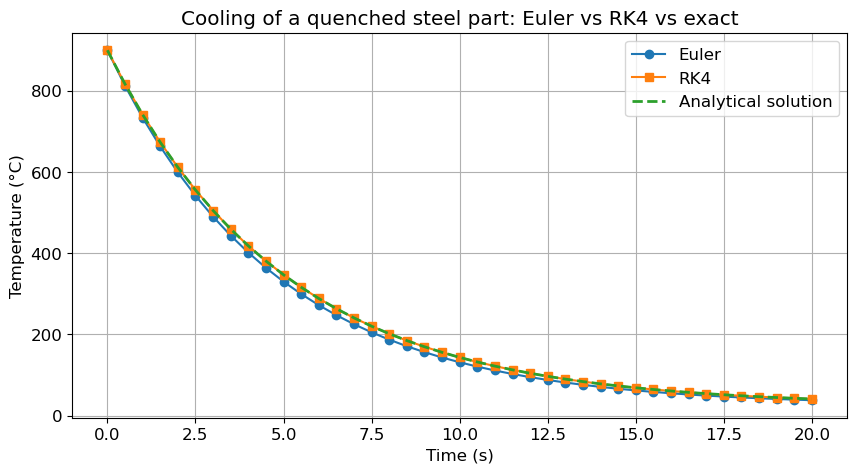

Final temperature at t = 20 s (Euler): 37.933 °C
Final temperature at t = 20 s (RK4):   41.026 °C
Final temperature at t = 20 s (Exact): 41.026 °C


In [3]:
# Q5: RK4, Euler, and analytical solution on the same plot
import numpy as np
import matplotlib.pyplot as plt

T0 = 900.0
T_bath = 25.0
k = 0.20
h = 0.5

def dTdt(t, T):
  return -k * (T - T_bath)

t = np.arange(0.0, 20.0 + h, h)

# Euler
T_euler = np.zeros_like(t)
T_euler[0] = T0
for i in range(len(t) - 1):
  T_euler[i + 1] = T_euler[i] + h * dTdt(t[i], T_euler[i])

# RK4
T_rk4 = np.zeros_like(t)
T_rk4[0] = T0
for i in range(len(t) - 1):
  ti = t[i]
  Ti = T_rk4[i]
  
  k1 = dTdt(ti, Ti)
  k2 = dTdt(ti + h / 2, Ti + h * k1 / 2)
  k3 = dTdt(ti + h / 2, Ti + h * k2 / 2)
  k4 = dTdt(ti + h, Ti + h * k3)
  
  T_rk4[i + 1] = Ti + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

# Analytical solution
T_exact = T_bath + (T0 - T_bath) * np.exp(-k * t)

plt.figure()
plt.plot(t, T_euler, 'o-', label='Euler')
plt.plot(t, T_rk4, 's-', label='RK4')
plt.plot(t, T_exact, '--', linewidth=2, label='Analytical solution')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Cooling of a quenched steel part: Euler vs RK4 vs exact')
plt.grid(True)
plt.legend()
plt.show()

print(f'Final temperature at t = 20 s (Euler): {T_euler[-1]:.3f} °C')
print(f'Final temperature at t = 20 s (RK4):   {T_rk4[-1]:.3f} °C')
print(f'Final temperature at t = 20 s (Exact): {T_exact[-1]:.3f} °C')


### Q6. What makes RK4 different from Euler's method?

RK4 uses some math magic to use more calculations in the same order time complexity to weigh out an average using multiple points to form the derivative, with a third-order error term. The error complexity is also higher, which is preferred, as errors are small. 
